In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/ch2_iirs_nic_3775_ref-002.tif
/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Training _code.py
/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-003/Internship 3/Ch-2 IIRS/new__ch2_iirs_ref_8507_substrips/new__ch2_iirs_ref_8507_substrip_9.tif
/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-003/Internship 3/Ch-2 IIRS/new__ch2_iirs_ref_8507_substrips/new__ch2_iirs_ref_8507_substrip_7.tif
/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-003/Internship 3/Ch-2 IIRS/new__ch2_iirs_ref_8507_substrips/new__ch2_iirs_ref_8507_substrip_4.tif
/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-00

In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [1]:
!pip install causal-conv1d>=1.2.0
!pip install mamba-ssm

  error: subprocess-exited-with-error
  
  × Building wheel for causal-conv1d (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for causal-conv1d
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (causal-conv1d)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.7/121.7 kB 5.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for mamba-ssm (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for mamba-ssm
Failed to build mamba-ssm
ERROR: ERROR: Failed to build installable wheels for

In [1]:
# ============================================================
# MBUNet-TCN: CUDA-safe replacement for Mamba/GRU MBUNet
# Works on Kaggle/Colab without mamba_ssm or causal-conv1d
# Input tensor format: (1, Bands, Height, Width)
# ============================================================

import gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


# ============================================================
# BASIC SETUP
# ============================================================

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


device = "cuda" if torch.cuda.is_available() else "cpu"

torch.backends.cudnn.benchmark = True


# ============================================================
# PREPROCESSING HELPERS
# ============================================================

def normalize_hsi(hsi, clip_negative=True, percentile=99.5):
    """
    hsi: numpy array in (H, W, B)
    returns normalized float32 hsi in (H, W, B)
    """
    hsi = np.asarray(hsi, dtype=np.float32)
    hsi = np.nan_to_num(hsi, nan=0.0, posinf=0.0, neginf=0.0)

    if clip_negative:
        hsi = np.where(hsi < 0, 0, hsi)

    scale = np.percentile(hsi, percentile)
    scale = max(scale, 1e-8)

    hsi = np.clip(hsi, 0, scale)
    hsi = hsi / scale

    return hsi.astype(np.float32)


def hwb_to_tensor(hsi_hwb):
    """
    hsi_hwb: (H, W, B)
    returns torch tensor: (1, B, H, W)
    """
    y = np.transpose(hsi_hwb, (2, 0, 1))[None, ...]
    return torch.tensor(y, dtype=torch.float32)


def bhw_to_tensor(hsi_bhw):
    """
    hsi_bhw: (B, H, W)
    returns torch tensor: (1, B, H, W)
    """
    y = hsi_bhw[None, ...]
    return torch.tensor(y, dtype=torch.float32)


def audit_hsi(name, arr):
    arr = np.asarray(arr)
    print("\n", name)
    print("shape:", arr.shape)
    print("dtype:", arr.dtype)
    print("finite:", np.isfinite(arr).all())
    print("nan count:", np.isnan(arr).sum())
    print("min/max:", np.nanmin(arr), np.nanmax(arr))
    print("p1/p50/p99:", np.nanpercentile(arr, [1, 50, 99]))


# ============================================================
# TCN SEQUENCE BLOCK
# ============================================================

class TCNBlock(nn.Module):
    """
    Input:  (B, SeqLen, C)
    Output: (B, SeqLen, C)

    Depthwise separable Conv1D block.
    This is much safer than GRU for Kaggle P100.
    """

    def __init__(
        self,
        d_model=16,
        hidden_mult=2,
        kernel_size=5,
        dilation=1,
        dropout_p=0.1
    ):
        super().__init__()

        hidden = d_model * hidden_mult
        padding = ((kernel_size - 1) * dilation) // 2

        self.net = nn.Sequential(
            nn.Conv1d(d_model, hidden, kernel_size=1),
            nn.GELU(),

            nn.Conv1d(
                hidden,
                hidden,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
                groups=hidden
            ),
            nn.GroupNorm(1, hidden),
            nn.GELU(),
            nn.Dropout(dropout_p),

            nn.Conv1d(hidden, d_model, kernel_size=1)
        )

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (B, L, C)
        residual = x

        x = x.transpose(1, 2)      # (B, C, L)
        x = self.net(x)
        x = x.transpose(1, 2)      # (B, L, C)

        return self.norm(x + residual)


class BiTCNSequence(nn.Module):
    """
    Bidirectional TCN replacement for bidirectional Mamba.

    Input:  (B, SeqLen, C)
    Output: (B, SeqLen, C)
    """

    def __init__(self, d_model=16, dropout_p=0.1):
        super().__init__()

        self.tcn1 = TCNBlock(
            d_model=d_model,
            hidden_mult=2,
            kernel_size=5,
            dilation=1,
            dropout_p=dropout_p
        )

        self.tcn2 = TCNBlock(
            d_model=d_model,
            hidden_mult=2,
            kernel_size=5,
            dilation=2,
            dropout_p=dropout_p
        )

    def forward_once(self, x):
        x = self.tcn1(x)
        x = self.tcn2(x)
        return x

    def forward(self, x):
        fwd = self.forward_once(x)

        rev = torch.flip(x, dims=[1])
        bwd = self.forward_once(rev)
        bwd = torch.flip(bwd, dims=[1])

        return 0.5 * (fwd + bwd)


# ============================================================
# LOCAL SPATIAL FEATURE EXTRACTOR
# ============================================================

class LocalSpatialFeatureExtractor(nn.Module):
    def __init__(self, in_channels, dropout_p=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.GroupNorm(4, 32),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout2d(dropout_p),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.GroupNorm(4, 32),
            nn.LeakyReLU(0.01, inplace=True),

            nn.Conv2d(32, 16, kernel_size=1),
            nn.GroupNorm(4, 16),
            nn.LeakyReLU(0.01, inplace=True)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# LOCAL SPECTRAL FEATURE EXTRACTOR
# ============================================================

class LocalSpectralFeatureExtractor(nn.Module):
    def __init__(self, dropout_p=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv3d(
                1,
                24,
                kernel_size=(4, 1, 1),
                padding=(1, 0, 0)
            ),
            nn.GroupNorm(6, 24),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout3d(dropout_p),

            nn.MaxPool3d(
                kernel_size=(2, 1, 1),
                stride=(2, 1, 1)
            ),

            nn.Conv3d(
                24,
                16,
                kernel_size=(4, 1, 1),
                padding=(1, 0, 0)
            ),
            nn.GroupNorm(4, 16),
            nn.LeakyReLU(0.01, inplace=True)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# GLOBAL SPATIAL TCN
# ============================================================

class GlobalSpatialTCN(nn.Module):
    """
    z: (B, C, H, W)
    Flatten spatially: (B, H*W, C)
    Apply bidirectional TCN.
    """

    def __init__(self, d_model=16, dropout_p=0.1):
        super().__init__()

        self.seq = BiTCNSequence(
            d_model=d_model,
            dropout_p=dropout_p
        )

        self.norm = nn.GroupNorm(4, d_model)
        self.act = nn.LeakyReLU(0.01, inplace=True)

    def forward(self, z):
        B, C, H, W = z.shape

        seq = z.permute(0, 2, 3, 1).contiguous().view(B, H * W, C)

        out = self.seq(seq)

        out = out.view(B, H, W, C).permute(0, 3, 1, 2).contiguous()

        return self.act(self.norm(z + out))


# ============================================================
# GLOBAL SPECTRAL TCN
# ============================================================

class GlobalSpectralTCN(nn.Module):
    """
    z: (B, C, D, H, W)
    Each pixel gets a spectral sequence: (B*H*W, D, C)
    Apply bidirectional TCN along spectral dimension.
    """

    def __init__(self, d_model=16, dropout_p=0.1):
        super().__init__()

        self.seq = BiTCNSequence(
            d_model=d_model,
            dropout_p=dropout_p
        )

        self.norm = nn.GroupNorm(4, d_model)
        self.act = nn.LeakyReLU(0.01, inplace=True)

    def forward(self, z):
        B, C, D, H, W = z.shape

        seq = z.permute(0, 3, 4, 2, 1).contiguous().view(B * H * W, D, C)

        out = self.seq(seq)

        out = out.view(B, H, W, D, C).permute(0, 4, 3, 1, 2).contiguous()

        return self.act(self.norm(z + out))


# ============================================================
# SHARED DECODER
# ============================================================

class WeightSharingDecoder(nn.Module):
    def __init__(self, n_endmembers, n_bands):
        super().__init__()

        self.endmember_layer = nn.Conv2d(
            n_endmembers,
            n_bands,
            kernel_size=1,
            bias=False
        )

    def forward(self, x):
        return F.relu(self.endmember_layer(x))

    def endmembers(self):
        # shape: (Bands, Endmembers)
        return self.endmember_layer.weight.squeeze(-1).squeeze(-1)


# ============================================================
# COMPLETE MBUNET-TCN
# ============================================================

class MBUNetTCN(nn.Module):
    def __init__(
        self,
        n_bands,
        n_endmembers,
        dropout_p=0.1,
        use_spatial_tcn=True,
        use_spectral_tcn=True,
        n_tcn_blocks=1
    ):
        super().__init__()

        self.n_bands = n_bands
        self.n_endmembers = n_endmembers
        self.use_spatial_tcn = use_spatial_tcn
        self.use_spectral_tcn = use_spectral_tcn

        # spatial branch
        self.local_spatial = LocalSpatialFeatureExtractor(
            in_channels=n_bands,
            dropout_p=dropout_p
        )

        self.spatial_tcn_blocks = nn.ModuleList([
            GlobalSpatialTCN(16, dropout_p)
            for _ in range(n_tcn_blocks)
        ])

        self.spatial_head = nn.Conv2d(
            16,
            n_endmembers,
            kernel_size=3,
            padding=1
        )

        # spectral branch
        self.local_spectral = LocalSpectralFeatureExtractor(
            dropout_p=dropout_p
        )

        self.spectral_tcn_blocks = nn.ModuleList([
            GlobalSpectralTCN(16, dropout_p)
            for _ in range(n_tcn_blocks)
        ])

        self.spectral_head = nn.Conv3d(
            16,
            n_endmembers,
            kernel_size=(4, 1, 1),
            padding=(1, 0, 0)
        )

        # shared endmember decoder
        self.decoder = WeightSharingDecoder(
            n_endmembers=n_endmembers,
            n_bands=n_bands
        )

    def forward(self, y):
        # y: (B, Bands, H, W)

        # ---------------------------
        # Spatial stream
        # ---------------------------
        z_spa = self.local_spatial(y)

        if self.use_spatial_tcn:
            for block in self.spatial_tcn_blocks:
                z_spa = block(z_spa)

        X1 = F.softmax(
            self.spatial_head(z_spa),
            dim=1
        )

        X1 = F.avg_pool2d(
            X1,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # ---------------------------
        # Spectral stream
        # ---------------------------
        y_3d = y.unsqueeze(1)   # (B, 1, Bands, H, W)

        z_spe = self.local_spectral(y_3d)

        if self.use_spectral_tcn:
            for block in self.spectral_tcn_blocks:
                z_spe = block(z_spe)

        spe_logits = self.spectral_head(z_spe)

        D_out = spe_logits.shape[2]

        X2 = F.max_pool3d(
            spe_logits,
            kernel_size=(D_out, 1, 1)
        ).squeeze(2)

        X2 = F.softmax(X2, dim=1)

        # ---------------------------
        # Shared decoder
        # ---------------------------
        Y1_hat = self.decoder(X1)
        Y2_hat = self.decoder(X2)

        return X1, X2, Y1_hat, Y2_hat

    def get_endmembers(self):
        return self.decoder.endmembers()


# ============================================================
# LOSSES
# ============================================================

def sad_loss(y_hat, y):
    B, L, H, W = y.shape

    y_hat_f = y_hat.permute(0, 2, 3, 1).reshape(-1, L)
    y_f = y.permute(0, 2, 3, 1).reshape(-1, L)

    dot = (y_hat_f * y_f).sum(dim=1)

    denom = (
        torch.norm(y_hat_f, dim=1)
        * torch.norm(y_f, dim=1)
    ).clamp(min=1e-8)

    cos = (dot / denom).clamp(-1 + 1e-7, 1 - 1e-7)

    return torch.mean(torch.acos(cos))


def mvc_loss(decoder):
    # E: (P, Bands)
    E = decoder.endmembers().t()

    P = E.shape[0]
    center = E.mean(dim=0, keepdim=True)

    return (1.0 / P) * torch.norm(E - center, dim=1).pow(2).sum()


def smoothness_loss(decoder):
    # decoder.endmembers(): (Bands, P)
    E = decoder.endmembers()
    return torch.mean(torch.abs(E[1:] - E[:-1]))


def compute_total_loss(
    X1,
    X2,
    Y1_hat,
    Y2_hat,
    Y,
    decoder,
    lambda_mse=1e-3,
    lambda_mvc=1e-4,
    lambda_sparse=1e-4,
    lambda_smooth=1e-3
):
    L_spa = (
        sad_loss(Y1_hat, Y)
        + lambda_mse * F.mse_loss(Y1_hat, Y)
        + lambda_mvc * mvc_loss(decoder)
    )

    L_spe = (
        sad_loss(Y2_hat, Y)
        + lambda_mse * F.mse_loss(Y2_hat, Y)
        + lambda_mvc * mvc_loss(decoder)
    )

    sparse = X1.abs().mean() + X2.abs().mean()
    smooth = smoothness_loss(decoder)

    total = (
        L_spa
        + L_spe
        + lambda_sparse * sparse
        + lambda_smooth * smooth
    )

    return total, L_spa.detach(), L_spe.detach()


# ============================================================
# VCA INITIALIZATION
# ============================================================

def vca(Y, n_endmembers, seed=0):
    """
    Y: (Bands, Pixels)
    returns E: (Bands, n_endmembers)
    """
    rng = np.random.default_rng(seed)

    Y = np.asarray(Y, dtype=np.float64)
    Y = np.nan_to_num(Y)

    L, N = Y.shape
    P = int(n_endmembers)

    Yn = Y / (np.linalg.norm(Y, axis=0, keepdims=True) + 1e-10)

    covariance = (Yn @ Yn.T) / max(N, 1)

    _, eigenvectors = np.linalg.eigh(covariance)

    projection = eigenvectors[:, -P:]
    Yp = projection.T @ Yn

    A = np.zeros((P, P))
    A[-1, 0] = 1.0

    E_idx = np.zeros(P, dtype=int)

    for i in range(P):
        w = rng.standard_normal(P)

        f = w - A @ np.linalg.pinv(A) @ w
        f = f / (np.linalg.norm(f) + 1e-10)

        v = f @ Yp
        idx = int(np.argmax(np.abs(v)))

        E_idx[i] = idx
        A[:, i] = Yp[:, idx]

    return Y[:, E_idx].astype(np.float32)


def init_decoder_vca(model, Y_full, max_pixels=100000):
    """
    Y_full: tensor (1, Bands, H, W), CPU or GPU
    """
    model_device = next(model.parameters()).device

    Y_np = Y_full.detach().cpu().numpy()

    _, L, H, W = Y_np.shape
    Y_2d = Y_np[0].reshape(L, -1)

    n_pixels = Y_2d.shape[1]

    if n_pixels > max_pixels:
        idx = np.random.choice(n_pixels, max_pixels, replace=False)
        Y_2d = Y_2d[:, idx]

    E_np = vca(Y_2d, model.n_endmembers)

    E_t = torch.tensor(
        E_np,
        dtype=torch.float32,
        device=model_device
    )

    with torch.no_grad():
        model.decoder.endmember_layer.weight.copy_(
            E_t.unsqueeze(-1).unsqueeze(-1)
        )

    print("Decoder initialized with VCA:", E_np.shape)


def clamp_decoder_nonnegative(model):
    with torch.no_grad():
        model.decoder.endmember_layer.weight.clamp_(0.0, 1.0)


# ============================================================
# PATCH SAMPLING
# ============================================================

def random_patch(Y, patch_hw=(64, 64)):
    """
    Y: tensor (1, Bands, H, W), already on GPU or CPU
    """
    _, _, H, W = Y.shape
    ph, pw = patch_hw

    ph = min(ph, H)
    pw = min(pw, W)

    i = np.random.randint(0, H - ph + 1)
    j = np.random.randint(0, W - pw + 1)

    return Y[:, :, i:i + ph, j:j + pw]


# ============================================================
# TRAINING
# ============================================================

def train_patches(
    model,
    Y_full,
    steps=2000,
    patch_hw=(64, 64),
    lr=1e-3,
    lambda_mse=1e-3,
    lambda_mvc=1e-4,
    lambda_sparse=1e-4,
    lambda_smooth=1e-3,
    log_every=100,
    use_amp=True,
    device="cuda"
):
    clear_gpu()

    model = model.to(device)
    Y_full = Y_full.to(device)

    init_decoder_vca(model, Y_full)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=500,
        gamma=0.8
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(use_amp and device == "cuda")
    )

    history = []

    model.train()

    for step in range(1, steps + 1):
        optimizer.zero_grad(set_to_none=True)

        Y_patch = random_patch(Y_full, patch_hw)

        with torch.amp.autocast(
            "cuda",
            enabled=(use_amp and device == "cuda")
        ):
            X1, X2, Y1_hat, Y2_hat = model(Y_patch)

            loss, l_spa, l_spe = compute_total_loss(
                X1,
                X2,
                Y1_hat,
                Y2_hat,
                Y_patch,
                model.decoder,
                lambda_mse=lambda_mse,
                lambda_mvc=lambda_mvc,
                lambda_sparse=lambda_sparse,
                lambda_smooth=lambda_smooth
            )

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        clamp_decoder_nonnegative(model)

        scheduler.step()

        history.append(loss.item())

        if step == 1 or step % log_every == 0:
            mem = 0.0
            if torch.cuda.is_available():
                mem = torch.cuda.memory_allocated() / 1024**3

            print(
                f"Step {step}/{steps} | "
                f"Loss={loss.item():.5f} | "
                f"Spa={l_spa.item():.5f} | "
                f"Spe={l_spe.item():.5f} | "
                f"GPU={mem:.2f} GB"
            )

    return model, history


# ============================================================
# TILED INFERENCE
# ============================================================

def tile_starts(size, tile):
    if size <= tile:
        return [0]

    starts = list(range(0, size - tile + 1, tile))

    if starts[-1] != size - tile:
        starts.append(size - tile)

    return starts


@torch.no_grad()
def unmix_tiled(
    model,
    Y_full,
    tile_hw=(128, 128),
    device="cuda"
):
    """
    Returns:
        E: (Bands, P)
        A: (P, H, W)
    """
    model = model.to(device)
    model.eval()

    Y_full = Y_full.to(device)

    _, B, H, W = Y_full.shape
    P = model.n_endmembers

    th, tw = tile_hw

    A_acc = torch.zeros(P, H, W, device=device)
    C_acc = torch.zeros(1, H, W, device=device)

    for i in tile_starts(H, th):
        for j in tile_starts(W, tw):
            patch = Y_full[:, :, i:i + th, j:j + tw]

            X1, X2, _, _ = model(patch)

            ph = patch.shape[2]
            pw = patch.shape[3]

            A_acc[:, i:i + ph, j:j + pw] += X1[0]
            C_acc[:, i:i + ph, j:j + pw] += 1.0

    A = (A_acc / C_acc.clamp(min=1.0)).detach().cpu().numpy()
    E = model.get_endmembers().detach().cpu().numpy()

    return E, A


def plot_history(history):
    plt.figure(figsize=(8, 4))
    plt.plot(history)
    plt.title("Training Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()


def plot_abundances(A, title="Abundance maps"):
    P = A.shape[0]
    cols = 4
    rows = int(np.ceil(P / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i in range(P):
        axes[i].imshow(A[i], cmap="viridis")
        axes[i].set_title(f"Endmember {i + 1}")
        axes[i].axis("off")

    for i in range(P, len(axes)):
        axes[i].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_endmembers(E):
    plt.figure(figsize=(10, 5))

    for i in range(E.shape[1]):
        plt.plot(E[:, i], label=f"E{i + 1}")

    plt.title("Learned Endmember Spectra")
    plt.xlabel("Band")
    plt.ylabel("Reflectance")
    plt.grid(True)
    plt.legend()
    plt.show()

## Cuprite Training 

dict_keys(['__header__', '__version__', '__globals__', 'X'])

 Cuprite raw
shape: (512, 614, 224)
dtype: float32
finite: True
nan count: 0
min/max: -50.0 12000.0
p1/p50/p99: [   0. 2703. 4668.]
GT keys: dict_keys(['__header__', '__version__', '__globals__', 'waveLength', 'M', 'nEnd', 'slctBnds', 'cood'])
waveLength (1, 224) float64
M (224, 12) float64
nEnd (1, 1) uint8
slctBnds (1, 188) uint8
cood (12, 1) object
slctBnds min/max: 3 220
first 10: [ 3  4  5  6  7  8  9 10 11 12]
last 10: [211 212 213 214 215 216 217 218 219 220]
Number of selected bands: 188
Cuprite clean: (512, 614, 188)

 Cuprite clean crop
shape: (250, 190, 188)
dtype: float32
finite: True
nan count: 0
min/max: 0.0 1.0
p1/p50/p99: [0.19378518 0.70565206 0.99363834]
Cuprite tensor: torch.Size([1, 188, 250, 190])
Parameters: 76144
Decoder initialized with VCA: (188, 12)
Step 1/3000 | Loss=0.11369 | Spa=0.05871 | Spe=0.05495 | GPU=0.04 GB
Step 100/3000 | Loss=0.06099 | Spa=0.03087 | Spe=0.03009 | GPU=0.04 GB
Step 200/300

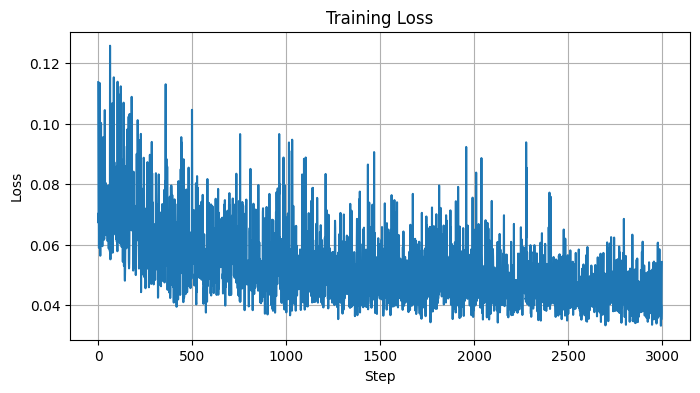

Endmembers: (188, 12)
Abundances: (12, 250, 190)
Abundance sum mean: 0.9938339


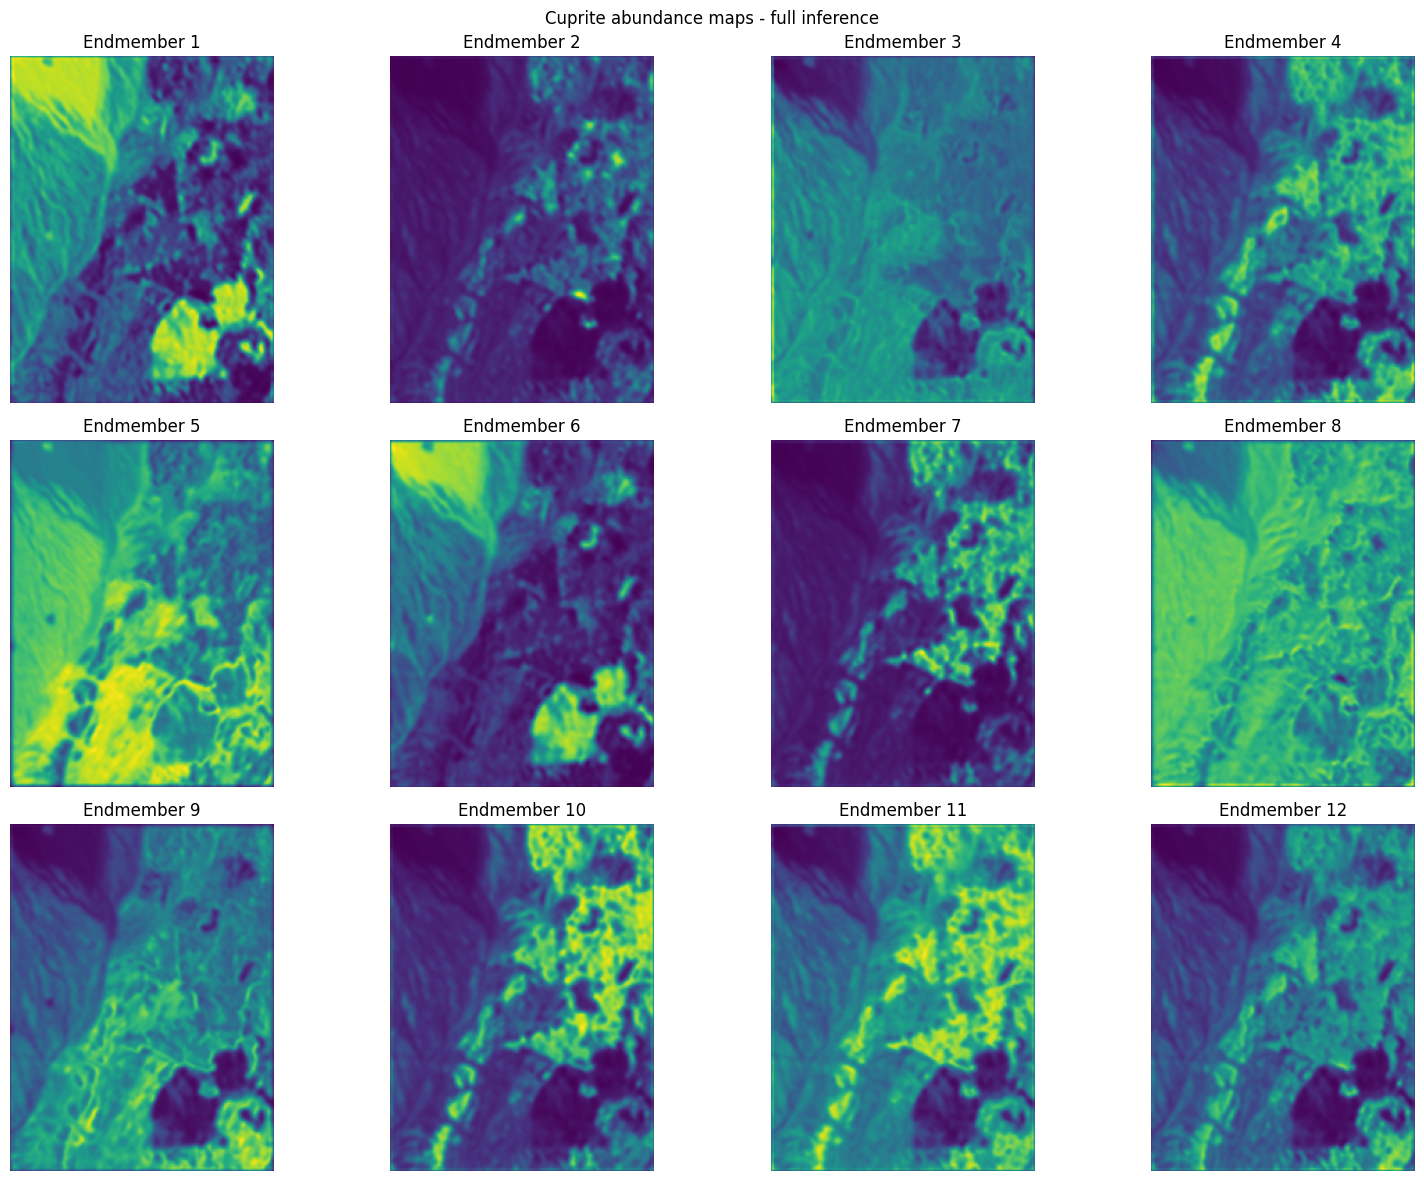

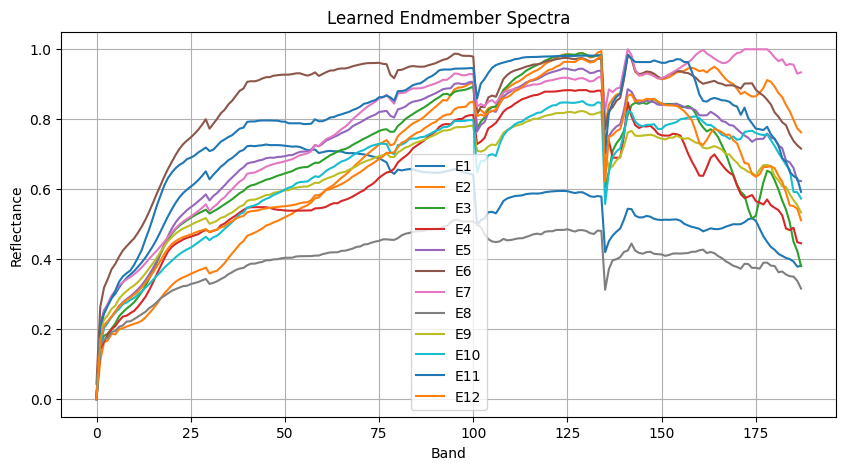

In [2]:
from scipy.io import loadmat
import numpy as np

clear_gpu()

CUPRITE_PATH = "/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-001/Internship 3/Cuprite/Cuprite.mat"
GT_PATH = "/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-001/Internship 3/Cuprite/groundTruth_Cuprite_nEnd12.mat"


cuprite_mat = loadmat(CUPRITE_PATH)
gt = loadmat(GT_PATH)
print(cuprite_mat.keys())

cuprite = cuprite_mat["X"].astype(np.float32)   # (512, 614, 224)
audit_hsi("Cuprite raw", cuprite)

print("GT keys:", gt.keys())

for k, v in gt.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape, v.dtype)


# ============================================================
# Use ground-truth selected bands
# ============================================================

gt_slct = gt["slctBnds"].squeeze().astype(int)

print("slctBnds min/max:", gt_slct.min(), gt_slct.max())
print("first 10:", gt_slct[:10])
print("last 10:", gt_slct[-10:])

# MATLAB uses 1-based indexing, Python uses 0-based indexing
if gt_slct.min() >= 1:
    good_bands = gt_slct - 1
else:
    good_bands = gt_slct

good_bands = good_bands.astype(int)

print("Number of selected bands:", len(good_bands))
# ------------------------------------------------------------
# Remove bad AVIRIS Cuprite bands
# Paper setup: Cuprite crop should become 250 x 190 x 188
# ------------------------------------------------------------

# These are 1-based bad bands commonly reported for Cuprite:
# 1-2, 104-113, 148-167, 221-224
#
# Convert to Python 0-based indexing:
# bad_bands = (
#     list(range(0, 2)) +        # 1-2
#     list(range(103, 113)) +    # 104-113
#     list(range(147, 167)) +    # 148-167
#     list(range(220, 224))      # 221-224
# )

# good_bands = [i for i in range(224) if i not in bad_bands]

cuprite_clean = cuprite[:, :, good_bands]

print("Cuprite clean:", cuprite_clean.shape)
# expected: (512, 614, 188)

# ------------------------------------------------------------
# Normalize AFTER band removal
# ------------------------------------------------------------

cuprite_clean = normalize_hsi(cuprite_clean)

# ------------------------------------------------------------
# Crop AFTER cleaning
# ------------------------------------------------------------

cuprite_crop = cuprite_clean[:250, :190, :]     # (250, 190, 188)

audit_hsi("Cuprite clean crop", cuprite_crop)

Y_cuprite = hwb_to_tensor(cuprite_crop)

print("Cuprite tensor:", Y_cuprite.shape)
# expected: torch.Size([1, 188, 250, 190])

n_bands = Y_cuprite.shape[1]
n_endmembers = 12

model = MBUNetTCN(
    n_bands=n_bands,
    n_endmembers=n_endmembers,
    dropout_p=0.05,
    use_spatial_tcn=True,
    use_spectral_tcn=True,
    n_tcn_blocks=1
)

params = sum(p.numel() for p in model.parameters())
print("Parameters:", params)

model, history = train_patches(
    model,
    Y_cuprite,
    steps=3000,
    patch_hw=(64, 64),
    lr=1e-3,
    lambda_mse=1e-3,
    lambda_mvc=1e-4,
    lambda_sparse=1e-4,
    lambda_smooth=1e-3,
    log_every=100,
    device=device
)

plot_history(history)

# ============================================================
# Full-image inference for Cuprite
# ============================================================

@torch.no_grad()
def unmix_full(model, Y, device="cuda"):
    model.eval()
    model = model.to(device)
    Y = Y.to(device)

    X1, X2, Y1_hat, Y2_hat = model(Y)

    E = model.get_endmembers().detach().cpu().numpy()
    A = X1[0].detach().cpu().numpy()

    return E, A, Y1_hat.detach().cpu(), Y2_hat.detach().cpu()


E_cuprite, A_cuprite, Y1_hat_full, Y2_hat_full = unmix_full(
    model,
    Y_cuprite,
    device=device
)

print("Endmembers:", E_cuprite.shape)
print("Abundances:", A_cuprite.shape)
print("Abundance sum mean:", A_cuprite.sum(axis=0).mean())

plot_abundances(A_cuprite, "Cuprite abundance maps - full inference")
plot_endmembers(E_cuprite)



# tiled inferences
# E_cuprite, A_cuprite = unmix_tiled(
#     model,
#     Y_cuprite,
#     tile_hw=(128, 128),
#     device=device
# )

# print("Endmembers:", E_cuprite.shape)
# print("Abundances:", A_cuprite.shape)
# print("Abundance sum mean:", A_cuprite.sum(axis=0).mean())

# plot_abundances(A_cuprite, "Cuprite abundance maps")
# plot_endmembers(E_cuprite)

## checking the metrics:

## Recontruction quality

In [3]:
# ============================================================
# Reconstruction quality
# ============================================================

@torch.no_grad()
def reconstruction_metrics(model, Y, device="cuda"):
    model.eval()
    model = model.to(device)
    Y = Y.to(device)

    X1, X2, Y1_hat, Y2_hat = model(Y)

    mse1 = F.mse_loss(Y1_hat, Y).item()
    mse2 = F.mse_loss(Y2_hat, Y).item()

    sad1 = sad_loss(Y1_hat, Y).item()
    sad2 = sad_loss(Y2_hat, Y).item()

    print("Spatial stream MSE:", mse1)
    print("Spectral stream MSE:", mse2)
    print("Spatial stream SAD:", sad1)
    print("Spectral stream SAD:", sad2)

reconstruction_metrics(model, Y_cuprite, device=device)

Spatial stream MSE: 0.006136016454547644
Spectral stream MSE: 0.004559140186756849
Spatial stream SAD: 0.02546181157231331
Spectral stream SAD: 0.018703492358326912


## Endmember spectral smoothness

In [6]:
def endmember_smoothness_score(E):
    # E: (Bands, P)
    return np.mean(np.abs(np.diff(E, axis=0)))

print("Smoothness:", endmember_smoothness_score(E_cuprite))

Smoothness: 0.01095279


## ground truth SAD comparision after reconstruction metrics :


In [4]:
# ============================================================
# Compare learned endmembers with Cuprite reference spectra
# ============================================================

from scipy.optimize import linear_sum_assignment

def spectral_angle_matrix(E_pred, E_ref):
    """
    E_pred: (Bands, P_pred)
    E_ref:  (Bands, P_ref)
    """
    E_pred = np.asarray(E_pred, dtype=np.float64)
    E_ref = np.asarray(E_ref, dtype=np.float64)

    E_pred = E_pred / (np.linalg.norm(E_pred, axis=0, keepdims=True) + 1e-8)
    E_ref = E_ref / (np.linalg.norm(E_ref, axis=0, keepdims=True) + 1e-8)

    cos = E_pred.T @ E_ref
    cos = np.clip(cos, -1 + 1e-8, 1 - 1e-8)

    return np.arccos(cos)


def match_endmembers(E_pred, E_ref):
    sad_mat = spectral_angle_matrix(E_pred, E_ref)

    row_ind, col_ind = linear_sum_assignment(sad_mat)
    matched_sad = sad_mat[row_ind, col_ind]

    print("Mean SAD radians:", matched_sad.mean())
    print("Mean SAD degrees:", np.degrees(matched_sad.mean()))
    print()

    for r, c, s in zip(row_ind, col_ind, matched_sad):
        print(
            f"Pred E{r+1:02d} -> Ref {c+1:02d} | "
            f"SAD={s:.4f} rad | {np.degrees(s):.2f} deg"
        )

    return row_ind, col_ind, matched_sad, sad_mat


# Reference spectra from GT file
E_ref_224 = gt["M"].astype(np.float64)      # (224, 12)

# Select the same 188 bands used for training
E_ref_188 = E_ref_224[good_bands, :]        # (188, 12)

row_ind, col_ind, matched_sad, sad_mat = match_endmembers(
    E_cuprite,
    E_ref_188
)

Mean SAD radians: 0.13193487389510347
Mean SAD degrees: 7.559311444780169

Pred E01 -> Ref 01 | SAD=0.1546 rad | 8.86 deg
Pred E02 -> Ref 11 | SAD=0.1091 rad | 6.25 deg
Pred E03 -> Ref 09 | SAD=0.0945 rad | 5.41 deg
Pred E04 -> Ref 06 | SAD=0.1564 rad | 8.96 deg
Pred E05 -> Ref 04 | SAD=0.2118 rad | 12.14 deg
Pred E06 -> Ref 07 | SAD=0.1549 rad | 8.87 deg
Pred E07 -> Ref 10 | SAD=0.0665 rad | 3.81 deg
Pred E08 -> Ref 12 | SAD=0.1581 rad | 9.06 deg
Pred E09 -> Ref 02 | SAD=0.0770 rad | 4.41 deg
Pred E10 -> Ref 03 | SAD=0.2107 rad | 12.07 deg
Pred E11 -> Ref 08 | SAD=0.0883 rad | 5.06 deg
Pred E12 -> Ref 05 | SAD=0.1014 rad | 5.81 deg


## compare against VCA

In [5]:
# Compare VCA initialization vs trained model against GT spectra

Y_2d = Y_cuprite[0].numpy().reshape(Y_cuprite.shape[1], -1)

E_vca = vca(Y_2d, 12, seed=0)   # (188, 12)

print("VCA vs reference:")
_, _, sad_vca, _ = match_endmembers(E_vca, E_ref_188)

print("\nTrained model vs reference:")
_, _, sad_model, _ = match_endmembers(E_cuprite, E_ref_188)

print("\nMean SAD VCA:", sad_vca.mean())
print("Mean SAD model:", sad_model.mean())
print("Improvement:", sad_vca.mean() - sad_model.mean())

VCA vs reference:
Mean SAD radians: 0.13027210232516315
Mean SAD degrees: 7.464041651528246

Pred E01 -> Ref 01 | SAD=0.1618 rad | 9.27 deg
Pred E02 -> Ref 11 | SAD=0.0590 rad | 3.38 deg
Pred E03 -> Ref 06 | SAD=0.1248 rad | 7.15 deg
Pred E04 -> Ref 05 | SAD=0.0832 rad | 4.77 deg
Pred E05 -> Ref 04 | SAD=0.2172 rad | 12.44 deg
Pred E06 -> Ref 07 | SAD=0.1325 rad | 7.59 deg
Pred E07 -> Ref 10 | SAD=0.0731 rad | 4.19 deg
Pred E08 -> Ref 12 | SAD=0.1597 rad | 9.15 deg
Pred E09 -> Ref 02 | SAD=0.0893 rad | 5.12 deg
Pred E10 -> Ref 03 | SAD=0.2313 rad | 13.25 deg
Pred E11 -> Ref 08 | SAD=0.0876 rad | 5.02 deg
Pred E12 -> Ref 09 | SAD=0.1438 rad | 8.24 deg

Trained model vs reference:
Mean SAD radians: 0.13193487389510347
Mean SAD degrees: 7.559311444780169

Pred E01 -> Ref 01 | SAD=0.1546 rad | 8.86 deg
Pred E02 -> Ref 11 | SAD=0.1091 rad | 6.25 deg
Pred E03 -> Ref 09 | SAD=0.0945 rad | 5.41 deg
Pred E04 -> Ref 06 | SAD=0.1564 rad | 8.96 deg
Pred E05 -> Ref 04 | SAD=0.2118 rad | 12.14 deg
P

Plot matched spectra
ou should visually compare each learned endmember against its matched reference:

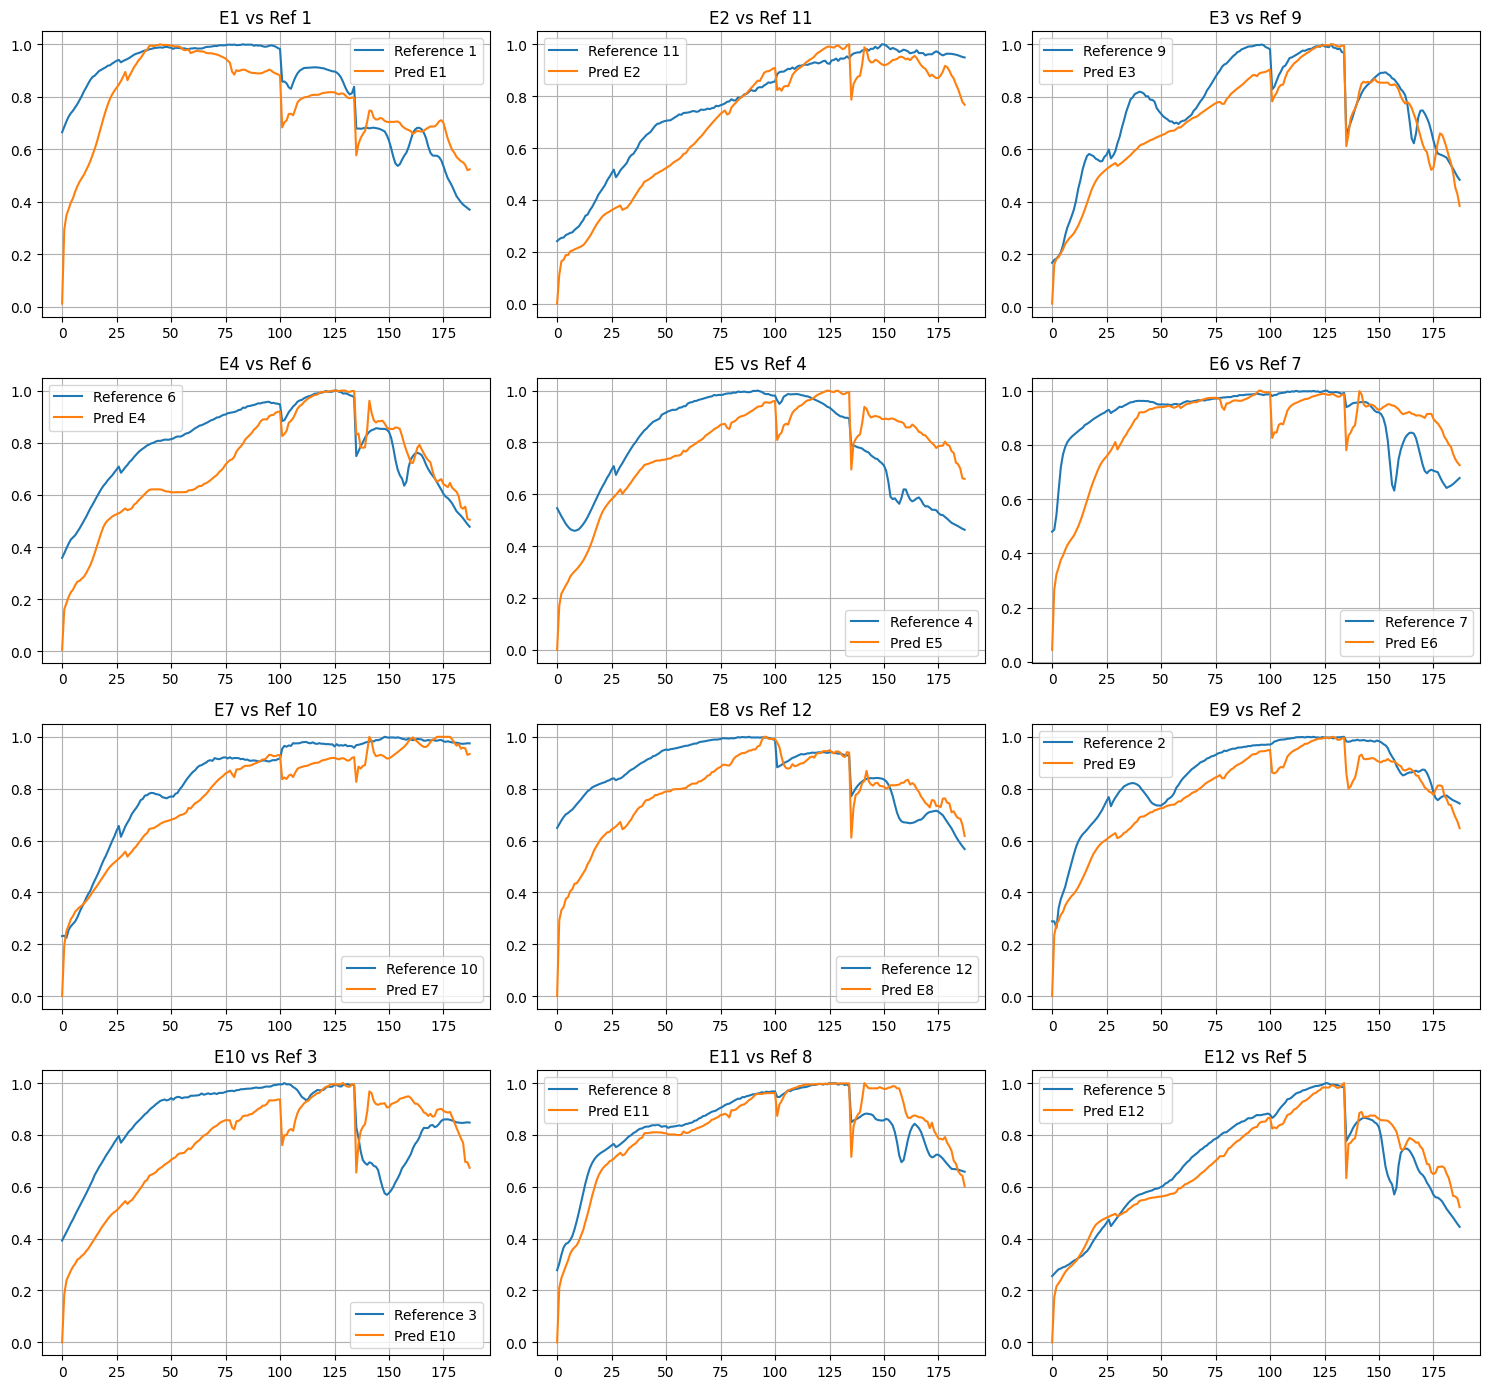

In [6]:
def plot_matched_spectra(E_pred, E_ref, row_ind, col_ind):
    n = len(row_ind)
    cols = 3
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
    axes = np.array(axes).reshape(-1)

    for idx, (r, c) in enumerate(zip(row_ind, col_ind)):
        ax = axes[idx]

        pred = E_pred[:, r]
        ref = E_ref[:, c]

        pred = pred / (pred.max() + 1e-8)
        ref = ref / (ref.max() + 1e-8)

        ax.plot(ref, label=f"Reference {c+1}")
        ax.plot(pred, label=f"Pred E{r+1}")
        ax.set_title(f"E{r+1} vs Ref {c+1}")
        ax.grid(True)
        ax.legend()

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

plot_matched_spectra(E_cuprite, E_ref_188, row_ind, col_ind)

## This is the end of Cuprite training 

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data")

CUPRITE_MAT = ROOT / "Internship 3-20260504T055941Z-3-001/Internship 3/Cuprite/Cuprite.mat"
CUPRITE_GT  = ROOT / "Internship 3-20260504T055941Z-3-001/Internship 3/Cuprite/groundTruth_Cuprite_nEnd12.mat"

M3_MAT = ROOT / "Internship 3-20260504T055941Z-3-001/Internship 3/Ch-1 M3/ch1_ref_355.mat"

IIRS_FULL = ROOT / "ch2_iirs_nic_3775_ref-002.tif"

IIRS_SUBSTRIP_DIRS = [
    ROOT / "Internship 3-20260504T055941Z-3-003/Internship 3/Ch-2 IIRS/new__ch2_iirs_ref_8507_substrips",
    ROOT / "Internship 3-20260504T055941Z-3-001/Internship 3/Ch-2 IIRS/new__ch2_iirs_ref_8507_substrips",
]

iirs_substrips = []
for d in IIRS_SUBSTRIP_DIRS:
    iirs_substrips.extend(sorted(d.glob("*.tif")))

print("Cuprite:", CUPRITE_MAT.exists(), CUPRITE_MAT)
print("Cuprite GT:", CUPRITE_GT.exists(), CUPRITE_GT)
print("M3:", M3_MAT.exists(), M3_MAT)
print("IIRS full:", IIRS_FULL.exists(), IIRS_FULL)
print("IIRS substrips:", len(iirs_substrips))
print(iirs_substrips[:5])


Cuprite: True /kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-001/Internship 3/Cuprite/Cuprite.mat
Cuprite GT: True /kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-001/Internship 3/Cuprite/groundTruth_Cuprite_nEnd12.mat
M3: True /kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-001/Internship 3/Ch-1 M3/ch1_ref_355.mat
IIRS full: True /kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/ch2_iirs_nic_3775_ref-002.tif
IIRS substrips: 50
[PosixPath('/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-003/Internship 3/Ch-2 IIRS/new__ch2_iirs_ref_8507_substrips/new__ch2_iirs_ref_8507_substrip_1.tif'), PosixPath('/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Addit

In [3]:
!pip install spectral rasterio tifffile -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 5.4 MB/s eta 0:00:0000:01


Data exploration and preperation :

In [6]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
import rasterio
import tifffile as tiff
def normalize(img):
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

def show_rgb(hsi, bands=[30,20,10], title="RGB"):
    rgb = np.stack([
        hsi[:,:,bands[0]],
        hsi[:,:,bands[1]],
        hsi[:,:,bands[2]]
    ], axis=-1)

    rgb = normalize(rgb)

    plt.figure(figsize=(8,8))
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

def plot_random_spectra(hsi, n=5):
    H,W,B = hsi.shape

    plt.figure(figsize=(10,5))

    for i in range(n):
        x = np.random.randint(0,H)
        y = np.random.randint(0,W)

        plt.plot(hsi[x,y,:], label=f"({x},{y})")

    plt.xlabel("Band")
    plt.ylabel("Reflectance")
    plt.title("Random Spectral Signatures")
    plt.legend()
    plt.show()

In [6]:
CUPRITE_PATH = r"/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-001/Internship 3/Cuprite/Cuprite.mat"

data = loadmat(CUPRITE_PATH)

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X'])


In [7]:
for k,v in data.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)

X (512, 614, 224)


In [9]:
hsi = data['X']   # CHANGE if needed

print("Shape:", hsi.shape)
print("Min:", hsi.min())
print("Max:", hsi.max())

NameError: name 'data' is not defined

In [12]:
hsi[100,200,:]

array([    0,     0,   -50,   686,   869,   911,  1006,  1061,  1123,
        1154,  1195,  1211,  1262,  1293,  1346,  1403,  1466,  1515,
        1604,  1667,  1735,  1792,  1848,  1892,  1943,  1963,  1998,
        2021,  2043,  2066,  2101,  2135,  2074,  2109,  2130,  2190,
        2214,  2268,  2291,  2323,  2371,  2386,  2452,  2459,  2464,
        2484,  2491,  2519,  2526,  2541,  2543,  2555,  2550,  2553,
        2570,  2594,  2599,  2591,  2597,  2608,  2656,  2645,  2663,
        2691,  2704,  2718,  2732,  2763,  2774,  2779,  2807,  2839,
        2861,  2883,  2893,  2903,  2921,  2935,  2936,  2951,  2856,
        2858,  2928,  2960,  2978,  2979,  3016,  3012,  3010,  3034,
        3040,  3060,  3061,  3088,  3104,  3114,  3135,  3161,  3141,
        3159,  3158,  3157,  3166,  3128,  3092,  3037,  2829,     0,
           0,     0,     0,  2488, 11812,  2784,  2710,  2747,  2805,
        2865,  2766,  2900,  2981,  3018,  3032,  3070,  3059,  3094,
        3103,  3112,

In [8]:
show_rgb(hsi, [100,60,20], "Cuprite RGB")

NameError: name 'hsi' is not defined

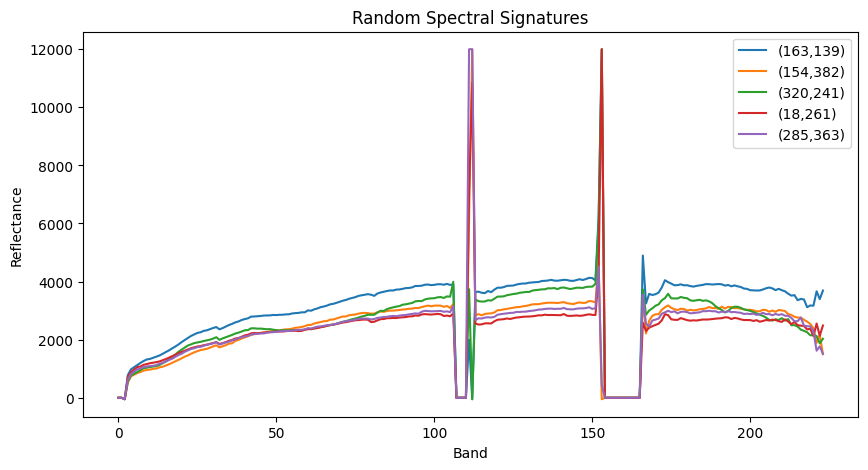

In [14]:
plot_random_spectra(hsi)

M3 exploration


In [15]:
M3_PATH = r"/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-001/Internship 3/Ch-1 M3/ch1_ref_355.mat"

m3 = loadmat(M3_PATH)

print(m3.keys())

for k,v in m3.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)

dict_keys(['__header__', '__version__', '__globals__', 'data'])
data (85, 2995, 304)


In [43]:
m3_hsi = m3['data']   # CHANGE if needed

print(m3_hsi.shape)

(85, 2995, 304)


In [44]:
valid_mask = (m3_hsi != -999)

valid_values = m3_hsi[valid_mask]

min_val = valid_values.min()
max_val = valid_values.max()

m3_hsi = np.where(m3_hsi == -999, min_val, m3_hsi)

In [48]:
m3_hsi = m3_hsi[:,:,2:]

In [46]:
m3_hsi = np.transpose(m3_hsi, (1,2,0))

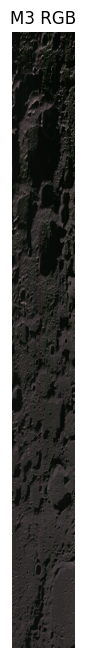

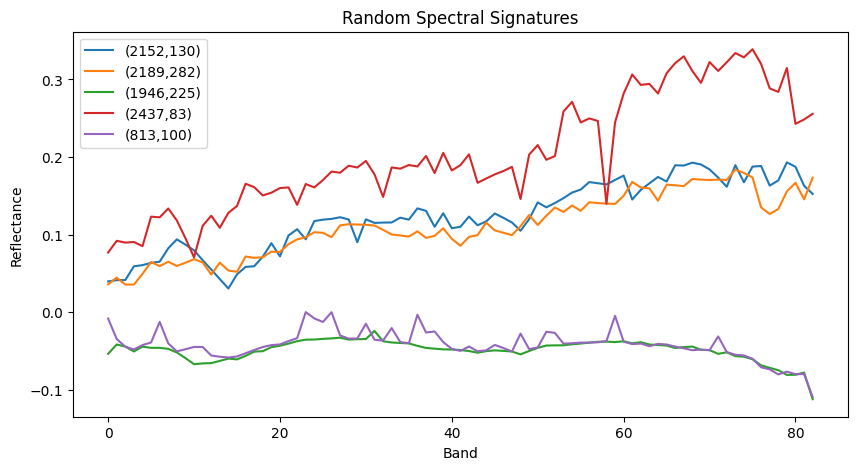

(2995, 302, 83)
-0.48883694 1.6278384


In [49]:
show_rgb(m3_hsi, [50,30,40], "M3 RGB")
plot_random_spectra(m3_hsi)
#plot_random_spectra(m3_hsi)
print(m3_hsi.shape)
print(m3_hsi.min(), m3_hsi.max())

The M3 data is in the format of (H,W,B)

In [34]:
print("Shape:", m3_hsi.shape)

band_axis = np.argmax(m3_hsi.shape)

print("Likely spectral axis:", band_axis)

Shape: (85, 2995, 304)
Likely spectral axis: 1


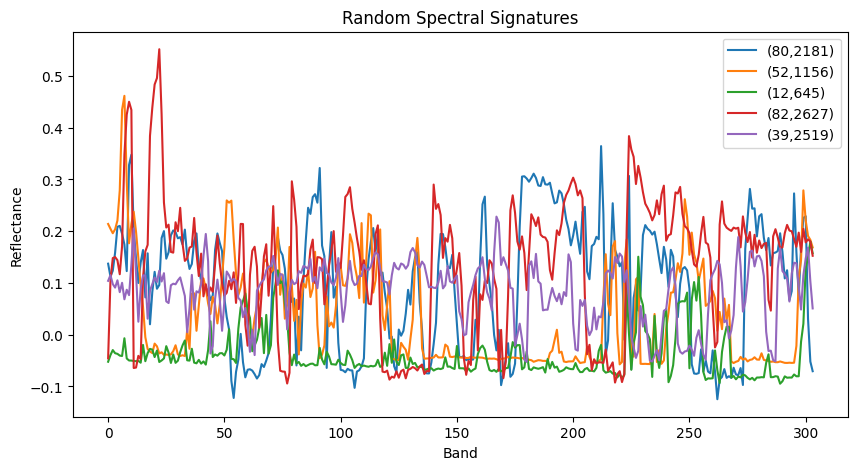

In [25]:
plot_random_spectra(m3_hsi)

In [26]:
IIRS_MAIN_PATH = r"/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/ch2_iirs_nic_3775_ref-002.tif"

with rasterio.open(IIRS_MAIN_PATH) as src:
    print(src.profile)

    data = src.read()

print(data.shape)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 250, 'height': 16503, 'count': 256, 'crs': None, 'transform': Affine(1.0, 0.0, 0.0,
       0.0, 1.0, 0.0), 'blockxsize': 250, 'blockysize': 1, 'tiled': False, 'interleave': 'band'}
(256, 16503, 250)


## Training with cuprite

Preprocessing the data 

In [ ]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Load Cuprite
# ---------------------------------------------------------

CUPRITE_PATH = "/kaggle/input/datasets/abhigyanpendyala/additional-project-data/Additional_project_data/Internship 3-20260504T055941Z-3-001/Internship 3/Cuprite/Cuprite.mat"

data = loadmat(CUPRITE_PATH)

print(data.keys())

hsi = data['X']

print("Original shape:", hsi.shape)

# ---------------------------------------------------------
# Remove bad AVIRIS bands
# ---------------------------------------------------------

bad_bands = list(range(0,2)) + \
            list(range(104,113)) + \
            list(range(148,168)) + \
            list(range(220,224))

good_bands = [i for i in range(hsi.shape[2])
              if i not in bad_bands]

hsi = hsi[:,:,good_bands]

print("After band removal:", hsi.shape)

# ---------------------------------------------------------
# Crop to paper dimensions
# ---------------------------------------------------------

hsi = hsi[:250, :190, :]

print("After crop:", hsi.shape)

# ---------------------------------------------------------
# Remove invalid values
# ---------------------------------------------------------

hsi = np.nan_to_num(hsi)

# ---------------------------------------------------------
# Clip negatives
# ---------------------------------------------------------

hsi = np.clip(hsi, 0, None)

# ---------------------------------------------------------
# Normalize
# ---------------------------------------------------------

hsi = hsi.astype(np.float32)

hsi = (hsi - hsi.min()) / (
    hsi.max() - hsi.min() + 1e-8
)

print("Final shape:", hsi.shape)
print("Min:", hsi.min())
print("Max:", hsi.max())

visualising the cuprite

RGB

In [ ]:
def normalize(img):
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

def show_rgb(hsi, bands=[50,30,10], title="RGB"):

    rgb = np.stack([
        hsi[:,:,bands[0]],
        hsi[:,:,bands[1]],
        hsi[:,:,bands[2]]
    ], axis=-1)

    rgb = normalize(rgb)

    plt.figure(figsize=(8,8))
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

show_rgb(hsi, [50,30,10], "Cuprite RGB")

Spectral signatures

In [ ]:
def plot_random_spectra(hsi, n=5):

    H,W,B = hsi.shape

    plt.figure(figsize=(10,5))

    for _ in range(n):

        x = np.random.randint(0,H)
        y = np.random.randint(0,W)

        plt.plot(hsi[x,y,:])

    plt.xlabel("Band")
    plt.ylabel("Reflectance")
    plt.title("Random Spectral Signatures")
    plt.show()

plot_random_spectra(hsi)

Convert to MBUnet format 

In [ ]:
import torch

# (H,W,L) -> (L,H,W)
hsi_t = np.transpose(hsi, (2,0,1))

# add batch dimension
Y = torch.tensor(hsi_t).unsqueeze(0)

print(Y.shape)